In [101]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from urllib.request import urlopen
import matplotlib.pyplot as plt

In [102]:
data = pd.read_csv(urlopen("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"))
values = data["Passengers"].values.reshape(-1,1)

In [103]:
scaler = MinMaxScaler()
values = scaler.fit_transform(values)

In [104]:
seq_len = 12

X, y = [], []
for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])
    y.append(values[i+seq_len])

X = np.array(X)
y = np.array(y)

In [105]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [106]:
gru = nn.GRU(1, 64, batch_first=True)
fc = nn.Linear(64, 1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(list(gru.parameters()) + list(fc.parameters()), lr=0.01)

In [107]:
for epoch in range(500):
    optimizer.zero_grad()
    out, _ = gru(X_train)
    out = fc(out[:, -1])
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    out, _ = gru(X_test)
    preds = fc(out[:, -1])

In [108]:
rmse = np.sqrt(mean_squared_error(y_test.numpy(), preds.numpy()))
print("RMSE:", rmse)

mae = mean_absolute_error(y_test.numpy(), preds.numpy())
print("MAE:", mae)

mape = np.mean(np.abs((y_test.numpy() - preds.numpy()) / y_test.numpy())) * 100
print("MAPE:", mape, "%")
print("Accuracy:", 100 - mape , "%")

RMSE: 0.10792363630652237
MAE: 0.09216360002756119
MAPE: 13.813864 %
Accuracy: 86.186134 %


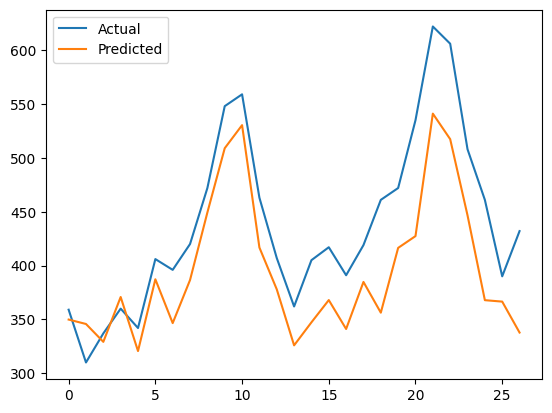

In [109]:
preds_plot = scaler.inverse_transform(preds.numpy())
y_test_plot = scaler.inverse_transform(y_test.numpy())

plt.plot(y_test_plot, label="Actual")
plt.plot(preds_plot, label="Predicted")
plt.legend()
plt.show()

In [110]:
last_seq = torch.tensor(values[-seq_len:].reshape(1, seq_len, 1), dtype=torch.float32)
out, _ = gru(last_seq)
next_month = fc(out[:, -1])
next_month = scaler.inverse_transform(next_month.detach().numpy())
print("Next Month Prediction:", next_month[0][0])

Next Month Prediction: 395.41614
